# 02 — Four-model comparison
Reproduce the reference paper's experimental logic for sequential distributions: RNN, BRNN, CA-RNN, and CA-BRNN. Here CA models use projected-PIT calibration; sequential regularization is isolated later.

In [1]:
import sys
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import CARNNConfig, TrainingConfig
from innovcal.data import simulate_multivariate_series
from innovcal.experiments import run_four_model_comparison
OUT = ROOT / 'results' / 'four_model'
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
values = simulate_multivariate_series(1200, regime='nonlinear', seed=2027)
training = TrainingConfig(epochs=150, batch_size=64, patience=20, seed=2027, bayesian_samples=2)
result = run_four_model_comparison(values, model_config=CARNNConfig(4, hidden_dim=32), training_config=training, lambda_cal=10.0, lambda_seq=0.0)
display(result.metrics.sort_values('pit_calibration_error'))
result.metrics.to_csv(OUT / 'metrics.csv', index=False)
for name, history in result.histories.items(): history.to_csv(OUT / f'{name.lower()}_history.csv', index=False)

,model,best_epoch,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
1,BRNN,30,5.374089,0.946542,1.252312,0.901042,3.266110,3.999146,0.000621,0.069762,0.055636,0.000632,0.063492,0.056886
3,CA-BRNN,30,5.373155,0.946224,1.251836,0.898958,3.256914,3.998432,0.000704,0.069059,0.057091,0.000729,0.062956,0.057972
2,CA-RNN,21,5.258455,0.935853,1.234322,0.917708,3.166444,3.878127,0.001220,0.071325,0.065383,0.001414,0.064327,0.068675
0,RNN,20,5.258137,0.936753,1.235388,0.916667,3.164351,3.877139,0.001224,0.073319,0.065472,0.001391,0.066184,0.069000


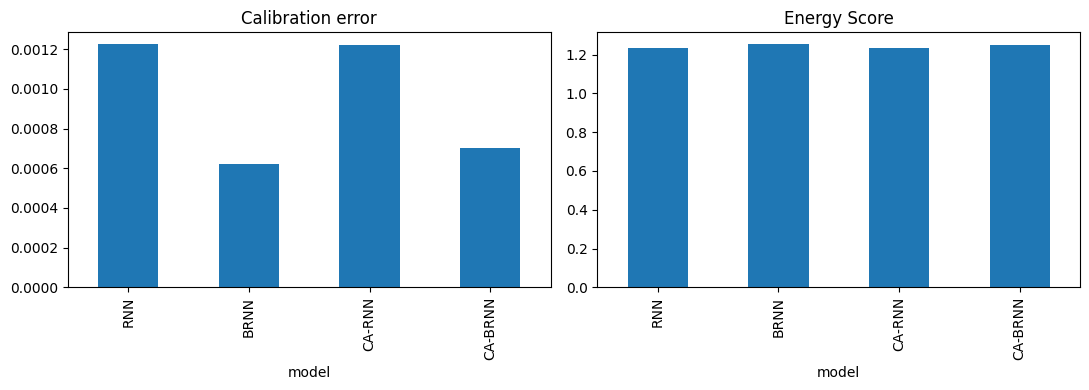

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
result.metrics.plot.bar(x='model', y='pit_calibration_error', ax=axes[0], legend=False, title='Calibration error')
result.metrics.plot.bar(x='model', y='energy_score', ax=axes[1], legend=False, title='Energy Score')
plt.tight_layout()